# XGBoost Model Training for Next-Hour Electricity Demand
This notebook loads the cleaned preprocessed dataset, splits chronologically, trains an XGBoost regressor, evaluates performance on 2024 test data, plots feature importance, and saves the model with `joblib`.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor, plot_importance
import joblib

file_path = 'preprocessed_data.csv'
df = pd.read_csv(file_path, parse_dates=['datetime']).sort_values('datetime').reset_index(drop=True)

print('Loaded dataset shape:', df.shape)
print('Years in dataset:', sorted(df['Year'].unique()))

Loaded dataset shape: (88932, 30)
Years in dataset: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [ ]:
train_df = df[df['Year'] <= 2023].copy()
test_df = df[df['Year'] == 2024].copy()

exclude_columns = ['datetime', 'Year', 'next_hour_demand_mw']
feature_columns = []
for c in df.columns:
    if c not in exclude_columns and df[c].dtype.kind in 'fiu': #float, or any int
        feature_columns.append(c)

X_train = train_df[feature_columns]
y_train = train_df['next_hour_demand_mw']
X_test = test_df[feature_columns]
y_test = test_df['next_hour_demand_mw']

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Selected numeric feature count:', len(feature_columns))
print('Example features:', feature_columns[:20])

Training rows: 76128
Test rows: 12804
Selected numeric feature count: 27
Example features: ['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'temperature', 'humidity', 'precipitation', 'GDP per capita (current US$)', 'GDP growth (annual %)', 'Inflation, consumer prices (annual %)', 'Population, total', 'Fossil fuel energy consumption (% of total)', 'Renewable energy consumption (% of total final energy consumption)']


In [10]:
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

model.fit(X_train, y_train)
print('Model training completed')

Model training completed


Evaluation on 2024 test set
---------------------------------
MAE: 357.68 MW
RMSE: 572.16 MW
MAPE: 3.12%

Top 15 feature importances:
                                  feature  importance
0                               demand_mw    0.660674
1                           generation_mw    0.185774
2                                   lag_1    0.094449
3                                  lag_24    0.011170
4                                    hour    0.008262
5                                   solar    0.003802
6                             temperature    0.003591
7                                   month    0.003388
8                           load_shedding    0.003348
9            GDP per capita (current US$)    0.003225
10                      Population, total    0.002970
11                                   coal    0.002144
12                                lag_168    0.001987
13                   india_bheramara_hvdc    0.001975
14  Inflation, consumer prices (annual %)    0.001907


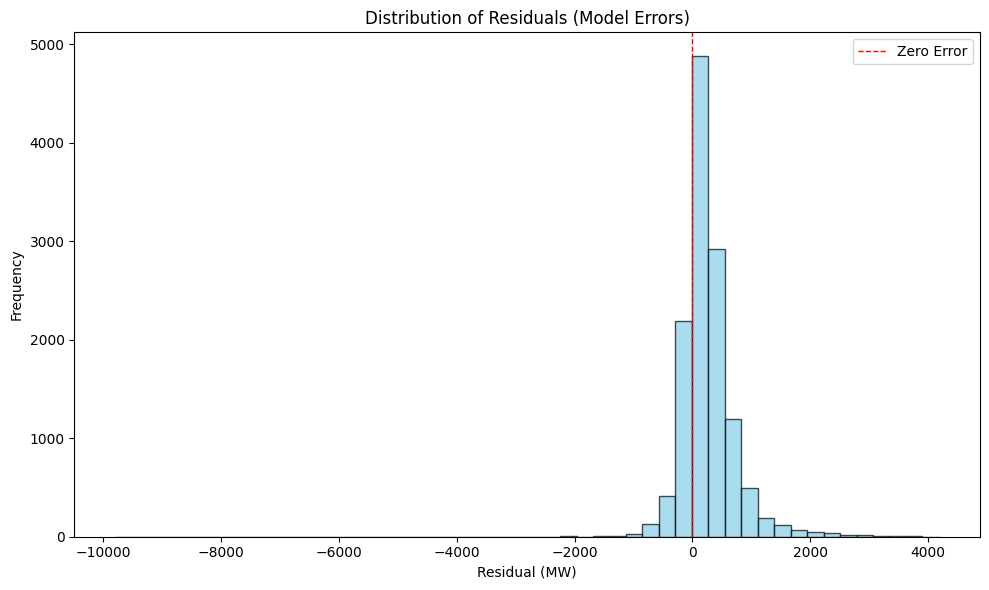

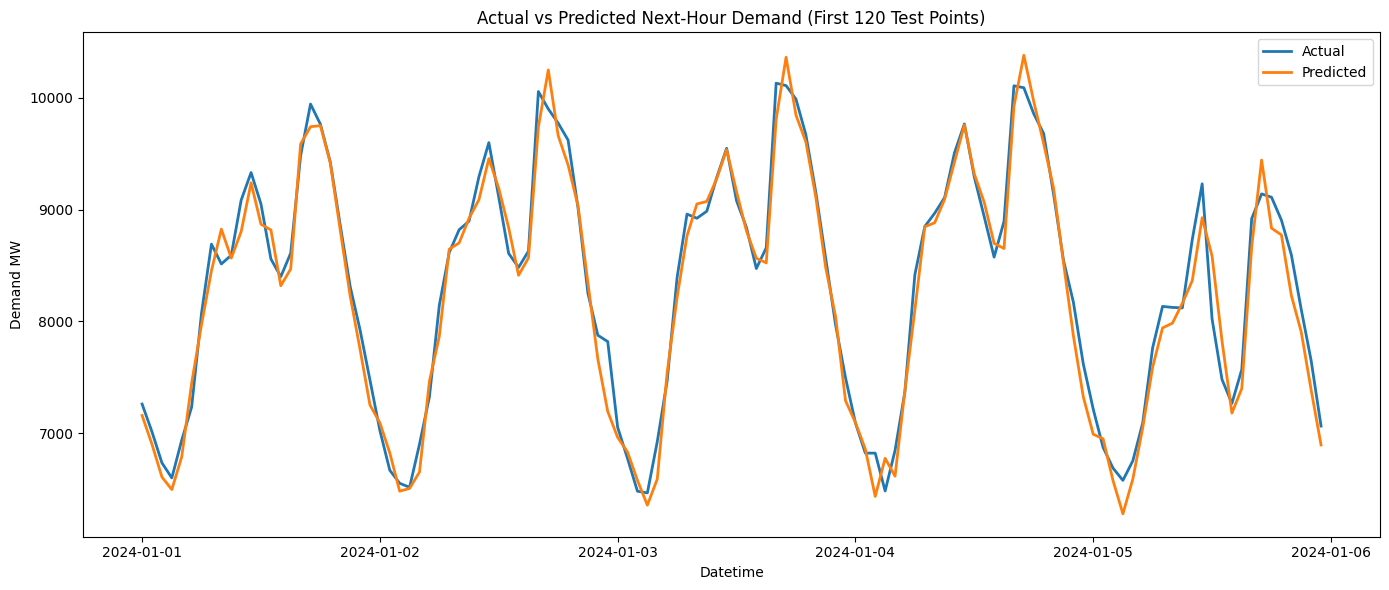

Model saved to xgboost_demand_forecast.pkl


In [11]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test.replace(0, np.nan))) * 100

print('Evaluation on 2024 test set')
print('---------------------------------')
print(f'MAE: {mae:.2f} MW')
print(f'RMSE: {rmse:.2f} MW')
print(f'MAPE: {mape:.2f}%')

importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)
print('\nTop 15 feature importances:')
print(importance_df.head(15))

# Plot residuals distribution for model error analysis
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Residuals (Model Errors)')
plt.xlabel('Residual (MW)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero Error')
plt.legend()
plt.tight_layout()
plt.show()

results = test_df[['datetime']].copy()
results['actual_next_hour_demand_mw'] = y_test.values
results['predicted_next_hour_demand_mw'] = y_pred

plt.figure(figsize=(14, 6))
plt.plot(results['datetime'].iloc[:120], results['actual_next_hour_demand_mw'].iloc[:120], label='Actual', linewidth=2)
plt.plot(results['datetime'].iloc[:120], results['predicted_next_hour_demand_mw'].iloc[:120], label='Predicted', linewidth=2)
plt.title('Actual vs Predicted Next-Hour Demand (First 120 Test Points)')
plt.xlabel('Datetime')
plt.ylabel('Demand MW')
plt.legend()
plt.tight_layout()
plt.show()

# Save the model
model_path = 'xgboost_demand_forecast.pkl'
joblib.dump(model, model_path)
print(f'Model saved to {model_path}')